In [1]:
import copy
import json
import numpy as np
import csv
import pandas as pd

import glob
import os
from pymatgen.core.structure import Structure
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.transformations.advanced_transformations import MonteCarloRattleTransformation as MCRattleTrans
from ase.io import read, write

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.interpolate import make_interp_spline
import re

splitbycap = '[A-Z][^A-Z]*'

matplotlib.rc('axes',edgecolor='k')
matplotlib.rc('xtick',labelsize=10)
matplotlib.rc('ytick',labelsize=10)
matplotlib.rc('axes',labelsize=16)
matplotlib.rc('axes',titlesize=16)
matplotlib.rc('axes',grid=False)

In [14]:
def get_data(filename):
    with open(filename,'r') as f:
        data = json.load(f)
    return data

def write_data(filename, data):
    with open(filename,'w') as f:
        json.dump(data, f)

def getMAD(list1,list2):
    if len(list1)!=len(list2):
        print('lists need to have the same dimensions')
        return 
    MAD_list = []
    for i in range(len(list1)):
        x1 = list1[i]
        x2 = list2[i]
        if not np.isnan(x1) and not np.isnan(x2):
            MAD_list.append(np.abs(x1-x2))
    MAD = np.sum(MAD_list)/len(MAD_list)
    return MAD, len(MAD_list)

def getMD(list1,list2):
    if len(list1)!=len(list2):
        print('lists need to have the same dimensions')
        return 
    MD_list = []
    divider = 0
    for i in range(len(list1)):
        x1 = list1[i]
        x2 = list2[i]
        if not np.isnan(x1) and not np.isnan(x2):
            MD_list.append(x1-x2)
            divider += 1
    MD = np.sum(MD_list)/divider
    return MD, len(MD_list)

def get_els_tuple(formula):
    '''
    :param: formula (string)
    :return: list of tuples containing elemental identity and stoichiometry
    '''
    splitbycap = '[A-Z][^A-Z]*'
    split_els = re.findall(splitbycap, formula) #split formula by capital letter
    els = []
    for split_el in split_els:
        #separate string into element and stoichiometry number
        el = [''.join([i for i in split_el if not i.isdigit()]), ''.join([i for i in split_el if i.isdigit()])] 
        if el[1]=='':
            el[1]='1'
        els.append(tuple(el))
    return els

def get_dHd(formula, dict):
    return dict[formula]['dHd'] if formula in dict else np.nan

def get_dHf(formula, dict):
    return dict[formula]['dHf'] if formula in dict else np.nan

def get_dHd_dHf(formula, dict):
    return get_dHd(formula, dict), get_dHf(formula, dict)

def get_Etot_per_atom(formula, dict):
    return dict[formula]['total_energy']/len(dict[formula]['st']['sites']) if formula in dict else np.nan



In [15]:
def split_by_elements(formula):
    '''
    :param: formula (string)
    :return: list of tuples containing elemental identity and stoichiometry
    '''
    splitbycap = '[A-Z][^A-Z]*'
    split_els = re.findall(splitbycap, formula) #split formula by capital letter
    els = []
    for split_el in split_els:
        #separate string into element and stoichiometry number
        el = [''.join([i for i in split_el if not i.isdigit()]), ''.join([i for i in split_el if i.isdigit()])] 
        if el[1]=='':
            el[1]='1'
        els.append(tuple(el))
    return els

def generate_alloy_site_dict(formula):
    '''
    this function does 2 things using the perovskite formula: 
    1. identifies perovskite type (single, 50:50, 25:75) and assigns site identities, returns a dictionary of site identities and perovskite type
    2. identifies problematic perovskite formulas, returns 'bad perovskite formula'
    :param formula: string of perovskite formula
    :return: dict if perovskite formula is good | str 'bad perovskite formula' if perovskite formula is bad 
    '''
    els_tuple = split_by_elements(formula)
    if len(els_tuple)==5: #double A site, alloy B site
        A1 = els_tuple[0][0]
        A2 = els_tuple[1][0]
        B1, xB1 = els_tuple[2][0], els_tuple[2][1]
        B2, xB2 = els_tuple[3][0], els_tuple[3][1]
        X = els_tuple[4][0]
        if xB1!=xB2:
            perov_type = '25:75'
        elif xB1==xB2:
            perov_type = '50:50'
    elif len(els_tuple)==4: 
        if els_tuple[-2][1]!='2': #alloy B site
            A1 = els_tuple[0][0]
            A2 = els_tuple[0][0]
            B1, xB1 = els_tuple[1][0], els_tuple[1][1]
            B2, xB2 = els_tuple[2][0], els_tuple[2][1]
            X = els_tuple[3][0]
            if xB1!=xB2:
                perov_type = '25:75'
            elif xB1==xB2:
                perov_type = '50:50'
        else: #double A site, single B site
            A1 = els_tuple[0][0]
            A2 = els_tuple[1][0]
            B1, xB1 = els_tuple[2][0], els_tuple[2][1]
            B2, xB2 = els_tuple[2][0], els_tuple[2][1]
            X = els_tuple[3][0]
            perov_type = 'single'
    elif len(els_tuple)==3: #single perovskite
        A1 = els_tuple[0][0]
        A2 = els_tuple[0][0]
        B1, xB1 = els_tuple[1][0], els_tuple[1][1]
        B2, xB2 = els_tuple[1][0], els_tuple[1][1]
        X = els_tuple[2][0]
        perov_type = 'single'
    
    # curate site_dict such that B1 is the deficient species and B2 is the excess species, if B1!=B2
    if perov_type=='single':
        site_dict = {'A1':A1, 'A2':A2, 'B1':B1, 'B2':B2, 'X':X, 'perov_type':perov_type}
    elif B1!=B2:
        if xB1==xB2 or xB1=='1': # 'or xB1=='1' is included as the deficient species is already B1
            site_dict = {'A1':A1, 'A2':A2, 'B1':B1, 'B2':B2, 'X':X, 'perov_type':perov_type}
        elif xB2=='1': #to designate the deficient species as B1 and the excess species as B2
            site_dict = {'A1':A1, 'A2':A2, 'B1':B2, 'B2':B1, 'X':X, 'perov_type':perov_type}
    else:
        return 'bad perovskite formula'
    
    return site_dict

In [21]:
#all DFTatMLIP calculated dHds
All_DFTatMLIP_dHd_new = get_data('data/DFT results/all_dhd_values.json')
All_DFTatMLIP_dHd = {k:v for k,v in All_DFTatMLIP_dHd_new.items() if v['dHd']<=0.2}

#template alloy overall dict
dat = get_data('data/DFT results/alloy_space_overall_dict_EMPTY.json')

# oqmd elemental reference energies (with corrections applied by oqmd)
oqmd_reference_energies = {}
#get list of elements
all_elements = []
with open('data/oqmd data/oqmd_elemental_reference.csv','r') as f:
    lines = csv.reader(f)
    for i, line in enumerate(lines):
        if i == 0: continue
        el = line[0]
        mu = float(line[3])
        nmu = float(line[2])
        oqmd_reference_energies[el] = mu
        all_elements.append(el)

In [ ]:
DFTatMLIP_result_1 = get_data('data/DFT results/DFTatMLIP_result_1.json')
DFTatMLIP_result_2 = get_data('data/DFT results/DFTatMLIP_result_2.json')
DFTatMLIP_result_3 = get_data('data/DFT results/DFTatMLIP_result_3.json')
DFTatMLIP_result_4 = get_data('data/DFT results/DFTatMLIP_result_4.json')
DFTatMLIP_result_5 = get_data('data/DFT results/DFTatMLIP_result_5.json')

All_DFTatMLIP_raw_results = {}
All_DFTatMLIP_raw_results.update(DFTatMLIP_result_1)
All_DFTatMLIP_raw_results.update(DFTatMLIP_result_2)
All_DFTatMLIP_raw_results.update(DFTatMLIP_result_3)
All_DFTatMLIP_raw_results.update(DFTatMLIP_result_4)
All_DFTatMLIP_raw_results.update(DFTatMLIP_result_5)

In [17]:
All_energy_dict_summarized = {}
for k, v in All_DFTatMLIP_dHd.items():
    if v['dHd'] < 0.2:
        tmp_dict = copy.deepcopy(v)
        Etot_atom = get_Etot_per_atom(k, All_DFTatMLIP_raw_results)
        Eg = All_DFTatMLIP_raw_results[k]['dos']['band_gap']['energy']
        tmp_dict.update({'Etot_atom':Etot_atom, 'Eg':Eg})
        All_energy_dict_summarized[k] = tmp_dict

# Make Dictionary of E_tots to prepare for Emix calculation

In [16]:
frac_str_list = ['0', '25', '50', '75', '100']
E_dict = {}
E_dict_B_isolated = {}
for alloy_set, v in dat.items():
    alloy_set_dict = {}
    alloy_els = get_els_tuple(alloy_set)
    if len(alloy_els)==5:
        formula_11 = alloy_els[0][0] + alloy_els[2][0] + alloy_els[4][0] + '3'
        formula_12 = alloy_els[1][0] + alloy_els[2][0] + alloy_els[4][0] + '3'
        formula_21 = alloy_els[0][0] + alloy_els[3][0] + alloy_els[4][0] + '3'
        formula_22 = alloy_els[1][0] + alloy_els[3][0] + alloy_els[4][0] + '3'
    else:
        formula_11 = alloy_els[0][0] + alloy_els[1][0] + alloy_els[3][0] + '3'
        formula_12 = alloy_els[0][0] + alloy_els[1][0] + alloy_els[3][0] + '3'
        formula_21 = alloy_els[0][0] + alloy_els[2][0] + alloy_els[3][0] + '3'
        formula_22 = alloy_els[0][0] + alloy_els[2][0] + alloy_els[3][0] + '3'
    Etot_single_11 = get_Etot_per_atom(formula_11, All_DFTatMLIP_raw_results)
    Etot_single_12 = get_Etot_per_atom(formula_12, All_DFTatMLIP_raw_results)
    Etot_single_21 = get_Etot_per_atom(formula_21, All_DFTatMLIP_raw_results)
    Etot_single_22 = get_Etot_per_atom(formula_22, All_DFTatMLIP_raw_results)
    
    dHd_11, dHf_11 = get_dHd_dHf(formula_11, All_DFTatMLIP_dHd)
    dHd_12, dHf_12 = get_dHd_dHf(formula_12, All_DFTatMLIP_dHd)
    dHd_21, dHf_21 = get_dHd_dHf(formula_21, All_DFTatMLIP_dHd)
    dHd_22, dHf_22 = get_dHd_dHf(formula_22, All_DFTatMLIP_dHd)
    
    single_1_dict = {'single_1':{'formula': formula_11, 'E_tot_atom': Etot_single_11, 'dHd': dHd_11, 'dHf': dHf_11},
                     'single_2':{'formula': formula_12, 'E_tot_atom': Etot_single_12, 'dHd': dHd_12, 'dHf': dHf_12}}
    single_2_dict = {'single_1':{'formula': formula_21, 'E_tot_atom': Etot_single_21, 'dHd': dHd_21, 'dHf': dHf_21},
                     'single_2':{'formula': formula_22, 'E_tot_atom': Etot_single_22, 'dHd': dHd_22, 'dHf': dHf_22}}
    
    if len(alloy_els)==5:
        formula_B_isolated_1 = alloy_els[0][0] + alloy_els[1][0] + alloy_els[2][0] + '2' + alloy_els[4][0] + '6'
        formula_B_isolated_2 = alloy_els[0][0] + alloy_els[1][0] + alloy_els[3][0] + '2' + alloy_els[4][0] + '6'
    else:
        formula_B_isolated_1 = alloy_els[0][0] + alloy_els[1][0] + alloy_els[3][0] + '3'
        formula_B_isolated_2 = alloy_els[0][0] + alloy_els[2][0] + alloy_els[3][0] + '3'
    Etot_B_isolated_1 = get_Etot_per_atom(formula_B_isolated_1, All_DFTatMLIP_raw_results)
    Etot_B_isolated_2 = get_Etot_per_atom(formula_B_isolated_2, All_DFTatMLIP_raw_results)
    
    dHd_B_isolated_1, dHf_B_isolated_1 = get_dHd_dHf(formula_B_isolated_1, All_DFTatMLIP_dHd)
    dHd_B_isolated_2, dHf_B_isolated_2 = get_dHd_dHf(formula_B_isolated_2, All_DFTatMLIP_dHd)
    
    single_B_isolated_1_dict = {'formula': formula_B_isolated_1, 'E_tot_atom': Etot_B_isolated_1, 'dHd': dHd_B_isolated_1, 'dHf': dHf_B_isolated_1}
    single_B_isolated_2_dict = {'formula': formula_B_isolated_1, 'E_tot_atom': Etot_B_isolated_1, 'dHd': dHd_B_isolated_1, 'dHf': dHf_B_isolated_1}
        
    for frac_str in frac_str_list:
        frac_dict = {}
        formula = v[frac_str]['formula']
        Etot_atom = get_Etot_per_atom(formula, All_DFTatMLIP_raw_results)
        dHd, dHf = get_dHd_dHf(formula, All_DFTatMLIP_dHd)
        
        frac_dict['formula'] = formula
        frac_dict['osm'] = {'sqs':{'E_tot_atom':Etot_atom, 'dHf':dHf, 'dHd':dHd}}
        
        alloy_set_dict[frac_str] = frac_dict
    E_dict[alloy_set] = copy.deepcopy(alloy_set_dict)
    E_dict[alloy_set]['0']['osm']['sqs'].update(single_1_dict)
    E_dict[alloy_set]['100']['osm']['sqs'].update(single_2_dict)
    
    E_dict_B_isolated[alloy_set] = copy.deepcopy(alloy_set_dict)
    E_dict_B_isolated[alloy_set]['0']['osm']['sqs'].update(single_B_isolated_1_dict)
    E_dict_B_isolated[alloy_set]['100']['osm']['sqs'].update(single_B_isolated_2_dict)
    

In [18]:
frac_str_list = ['0', '25', '50', '75', '100']
frac_flt_list = [0, 0.25, 0.5, 0.75, 1]
calced_E_dict = copy.deepcopy(E_dict)
calced_All_energy_dict_summarized = copy.deepcopy(All_energy_dict_summarized)
for alloy_set, v in E_dict.items():
    #for single perov (count ABX3 as endpoint) 
    Etot_linear_single_0 = (v['0']['osm']['sqs']['single_1']['E_tot_atom']+v['0']['osm']['sqs']['single_2']['E_tot_atom'])/2
    Etot_linear_single_100 = (v['100']['osm']['sqs']['single_1']['E_tot_atom']+v['100']['osm']['sqs']['single_2']['E_tot_atom'])/2
    dHd_11, dHd_12 = v['0']['osm']['sqs']['single_1']['dHd'], v['0']['osm']['sqs']['single_2']['dHd']
    dHd_21, dHd_22 = v['100']['osm']['sqs']['single_1']['dHd'], v['100']['osm']['sqs']['single_2']['dHd']
    formula_11, formula_12 = v['0']['osm']['sqs']['single_1']['formula'], v['0']['osm']['sqs']['single_2']['formula']
    formula_21, formula_22 = v['100']['osm']['sqs']['single_1']['formula'], v['100']['osm']['sqs']['single_2']['formula']
    
    single_formula_dict = {dHd_11:formula_11, dHd_12:formula_12,
                           dHd_21:formula_21, dHd_22:formula_22}
    dHd_linear_single_0 = (dHd_11+dHd_12)/2
    dHd_linear_single_100 = (dHd_21+dHd_22)/2
    
    #for isolated B-site only (count AA'B2X6 as endpoint)
    Etot_linear_single_B_isolated_0 = v['0']['osm']['sqs']['E_tot_atom']
    Etot_linear_single_B_isolated_100 = v['100']['osm']['sqs']['E_tot_atom']
    dHd_B_isolated_1 = v['0']['osm']['sqs']['dHd']
    dHd_B_isolated_2 = v['100']['osm']['sqs']['dHd']
    formula_B_isolated_1 = v['0']['formula']
    formula_B_isolated_2 = v['100']['formula']
    
    single_formula_B_isolated_dict = {dHd_B_isolated_1:formula_B_isolated_1, dHd_B_isolated_2:formula_B_isolated_2,}
    dHd_linear_B_isolated_0 = dHd_B_isolated_1
    dHd_linear_B_isolated_100 = dHd_B_isolated_2
        
    for frac_str in frac_str_list:
        frac = frac_flt_list[frac_str_list.index(frac_str)]
        dHd = v[frac_str]['osm']['sqs']['dHd']
        alloy_form = v[frac_str]['formula']
        
        Etot_linear = (1-frac)*(Etot_linear_single_0) + frac*(Etot_linear_single_100)
        dHd_linear = (1-frac)*(dHd_linear_single_0) + frac*(dHd_linear_single_100)
        dHmix = dHd - dHd_linear
        if np.nan not in [dHd_11,dHd_12,dHd_21,dHd_22]:
            dHd_min = min([dHd_11,dHd_12,dHd_21,dHd_22])
            dHd_max = max([dHd_11,dHd_12,dHd_21,dHd_22])
            formula_min = single_formula_dict[dHd_min]
            formula_max = single_formula_dict[dHd_max]
        else:
            dHd_min = np.nan
            dHd_max = np.nan
            formula_min = np.nan
            formula_max = np.nan
        component_dict = {'singles':[formula_11, formula_12, formula_21, formula_22],
                          'dHd_singles':[dHd_11, dHd_12, dHd_21, dHd_22],
                          'frac_singles':[1-frac,1-frac,frac,frac]}
        
        Etot_B_isolated_linear = (1-frac)*(Etot_linear_single_B_isolated_0) + frac*(Etot_linear_single_B_isolated_100)
        dHd_B_isolated_linear = (1-frac)*(dHd_linear_B_isolated_0) + frac*(dHd_linear_B_isolated_100)
        dHmix_B_isolated = dHd - dHd_B_isolated_linear
        if np.nan not in [dHd_11,dHd_12,dHd_21,dHd_22]:
            dHd_B_isolated_min = min([dHd_B_isolated_1,dHd_B_isolated_2])
            dHd_B_isolated_max = max([dHd_B_isolated_1,dHd_B_isolated_2])
            formula_B_isolated_min = single_formula_B_isolated_dict[dHd_B_isolated_min]
            formula_B_isolated_max = single_formula_B_isolated_dict[dHd_B_isolated_max]
        else:
            dHd_B_isolated_min = np.nan
            dHd_B_isolated_max = np.nan
            formula_B_isolated_min = np.nan
            formula_B_isolated_max = np.nan
        component_B_isolated_dict = {'singles':[formula_B_isolated_1, formula_B_isolated_2],
                                     'dHd_singles':[dHd_linear_B_isolated_0, dHd_linear_B_isolated_100],
                                     'frac_singles':[1-frac,frac]}
        
        # if np.isnan(dHd) and np.isnan(dHd_linear):
            # print(alloy_set, frac_str, dHd, dHd_linear, dHmix)
        
        # print(alloy_set, frac_str, dHd, dHd_linear)
        calced_E_dict[alloy_set][frac_str]['osm']['sqs'].update({'dHm': dHmix,'dHd_linear': dHd_linear,
                                                                 'Etot_linear': Etot_linear,
                                                                 'dHd_min': dHd_min,'dHd_max': dHd_max,
                                                                 'formula_min': formula_min,'formula_max': formula_max,
                                                                 'components': component_dict,
                                                                 
                                                                 'B_isolated':{'dHm': dHmix_B_isolated,'dHd_linear': dHd_B_isolated_linear,
                                                                               'Etot_linear': Etot_B_isolated_linear,
                                                                               'dHd_min': dHd_B_isolated_min,'dHd_max': dHd_B_isolated_max,
                                                                               'formula_min': formula_B_isolated_min,
                                                                               'formula_max': formula_B_isolated_max,
                                                                               'components': component_B_isolated_dict}
                                                                 }
                                                                )
        if alloy_form in calced_All_energy_dict_summarized:
            calced_All_energy_dict_summarized[alloy_form]['components'] = component_dict
            calced_All_energy_dict_summarized[alloy_form]['components_B_isolated'] = component_B_isolated_dict
        # else:
        #     print(alloy_form, dHd)
        # print(calced_E_dict[alloy_set][frac_str]['formula'], formula_min, formula_max, formula_B_isolated_min, formula_B_isolated_max)

In [19]:
for alloy_set, v in calced_E_dict.items():
    print(alloy_set, calced_E_dict[alloy_set]['0']['osm']['sqs']['single_1']['dHd'],calced_E_dict[alloy_set]['0']['osm']['sqs']['single_2']['dHd'], calced_E_dict[alloy_set]['100']['osm']['sqs']['single_1']['dHd'],calced_E_dict[alloy_set]['100']['osm']['sqs']['single_2']['dHd'])

RbCsTiSrBr6 0.17437075220675702 0.10947233620675689 0.026391974449500477 -0.009937348550494551
Rb2FeCoI6 0.1539881474569924 0.1539881474569924 0.19476406079032405 0.19476406079032405
RbCsMnCoI6 0.07664618921561317 0.07311152988227487 0.19476406079032405 0.17597252712365563
RbCsMgCaCl6 0.01018605220480584 0.013488873954806913 -0.003285316628525603 -0.009560086628524811
Rb2MnCoI6 0.07664618921561317 0.07664618921561317 0.19476406079032405 0.19476406079032405
Cs2CaCoF6 -0.004303775521332653 -0.004303775521332653 0.06289092885365921 0.06289092885365921
NaKCoZnF6 0.00827657214899613 0.021316046645332598 0.021281840148993147 0.034477837978664105
RbCsMgCrCl6 0.01018605220480584 0.013488873954806913 0.050246553704807795 0.06068890970480734
RbCsCdPbCl6 0.031302464704808575 0.02759316137146861 0.009376165371475231 -0.0006055836285261407
Rb2CoCuBr6 0.14426606586616586 0.14426606586616586 -0.005469789550498039 -0.005469789550498039
RbCsCrMnCl6 0.050246553704807795 0.06068890970480734 0.02651966013

### create 2 lists of values to plot: true dHd and linear combination dHd

In [22]:
def get_els_tuple(formula):
    '''
    :param: formula (string)
    :return: list of tuples containing elemental identity and stoichiometry
    '''
    splitbycap = '[A-Z][^A-Z]*'
    split_els = re.findall(splitbycap, formula) #split formula by capital letter
    els = []
    for split_el in split_els:
        #separate string into element and stoichiometry number
        el = [''.join([i for i in split_el if not i.isdigit()]), ''.join([i for i in split_el if i.isdigit()])] 
        if el[1]=='':
            el[1]='1'
        els.append(tuple(el))
    return els

def get_dHf(formula, Etot_atom, reference_dict = oqmd_reference_energies):
    '''
    calculate dHf from formula and Etot_atom using oqmd reference energies 
    :param formula: formula of compound of interest
    :param Etot_atom: DFT total energy of compound of interest
    :param reference_dict: provide dictionary of reference energies, default is oqmd_reference_energies
    :return: 
    '''
    els_tuple = get_els_tuple(formula)
    ref_energy = 0
    per_atom_normalizer = 0
    for el_tuple in els_tuple:
        el, stoich = el_tuple[0], int(el_tuple[1])
        E_ref = reference_dict[el]
        ref_energy += stoich*E_ref
        per_atom_normalizer += stoich
    dHf = Etot_atom - (ref_energy/per_atom_normalizer)
    return dHf

In [23]:
def append_to_dict_list(dict, key, alloy_set, sub_formula, value):
    if sub_formula in alloy_set:
        dict[key].append(value)

In [ ]:
formula_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
Etot_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
dHf_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
dHd_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
linear_Etot_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
linear_dHf_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
linear_dHd_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
dHm_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
min_dHd_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
max_dHd_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
most_stable_single_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
least_stable_single_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}
frac_identity_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}

frac_str_list = ['0', '25', '50', '75', '100']
frac_flt_list = [0, 0.25, 0.5, 0.75, 1]

interesting_list = []
missing_list = []
good_list = []
done_comp = []
for alloy_set, v in calced_E_dict.items():
    for frac_str in frac_str_list:
        formula = v[frac_str]['formula']
        frac = frac_flt_list[frac_str_list.index(frac_str)]
        # all alloys
        Etot = v[frac_str]['osm']['sqs']['E_tot_atom']
        dHf = get_dHf(formula, Etot)
        dHd = v[frac_str]['osm']['sqs']['dHd']
        Etot_linear = v[frac_str]['osm']['sqs']['Etot_linear']
        dHf_linear = get_dHf(formula, Etot_linear)
        dHd_linear = v[frac_str]['osm']['sqs']['dHd_linear']
        dHm = dHf - dHf_linear # or Etot_atom - Etot_linear
        dHd_min = v[frac_str]['osm']['sqs']['dHd_min']
        dHd_max = v[frac_str]['osm']['sqs']['dHd_max']
        formula_min = v[frac_str]['osm']['sqs']['formula_min']
        formula_max = v[frac_str]['osm']['sqs']['formula_max']
        
        if not formula in done_comp:
            done_comp.append(formula)
            if not np.isnan(dHd) and not np.isnan(dHd_linear) and dHd!=dHd_linear:# and frac_str not in ['0','100']:
                good_list.append(formula)
                for X in ['F', 'Cl', 'Br', 'I']:
                    append_to_dict_list(formula_dict, X, alloy_set, X+'6', formula)
                    append_to_dict_list(Etot_dict, X, alloy_set, X+'6', Etot)
                    append_to_dict_list(dHf_dict, X, alloy_set, X+'6', dHf)
                    append_to_dict_list(dHd_dict, X, alloy_set, X+'6', dHd)
                    append_to_dict_list(linear_Etot_dict, X, alloy_set, X+'6', Etot_linear)
                    append_to_dict_list(linear_dHf_dict, X, alloy_set, X+'6', dHf_linear)
                    append_to_dict_list(linear_dHd_dict, X, alloy_set, X+'6', dHd_linear)
                    append_to_dict_list(dHm_dict, X, alloy_set, X+'6', dHm)                    
                    append_to_dict_list(min_dHd_dict, X, alloy_set, X+'6', dHd_min)
                    append_to_dict_list(max_dHd_dict, X, alloy_set, X+'6', dHd_max)
                    append_to_dict_list(most_stable_single_dict, X, alloy_set, X+'6', formula_min)
                    append_to_dict_list(least_stable_single_dict, X, alloy_set, X+'6', formula_max)
                    append_to_dict_list(frac_identity_dict, X, alloy_set, X+'6', frac_str)
                
                if dHd-dHd_linear>0.1:
                    print(v[frac_str]['formula'], alloy_set, frac_str, dHd, dHd_linear)
                if dHf<dHf_linear:# and np.abs(dHd-dHd_linear)>0.005:
                    interesting_list.append(v[frac_str]['formula'])
                    # if dHd<0.05:
                    #     print(v[frac_str]['formula'], alloy_set, frac_str, dHd, dHd_linear)
                if dHd>0.3:
                    print(v[frac_str]['formula'], alloy_set, frac_str, dHd, dHd_linear)
            elif np.isnan(dHd):
                missing_list.append(formula)
            else:
                good_list.append(formula)

missing_list = list(set(missing_list))
good_list = list(set(good_list))

In [25]:
def append_to_dict_list(dict, key, alloy_set, sub_formula, value):
    if sub_formula in alloy_set:
        dict[key].append(value)

In [ ]:
def combine_data_dict_to_list(data_dict):
    combined_list = []
    halides = ['F', 'Cl', 'Br', 'I']
    for halide in halides:
        combined_list += data_dict[halide]
    return combined_list

In [28]:
def count_postive_negative(list1, list2):
    count_positive = 0
    count_negative = 0
    for i in range(len(list1)):
        if list1[i]>list2[i]:
            count_positive += 1
        elif list1[i]<list2[i]:
            count_negative += 1
    return count_positive, count_negative

positive_negative_dict = {}
for X in ['F', 'Cl', 'Br', 'I']:
    positive, negative = count_postive_negative(Etot_dict[X], linear_Etot_dict[X])
    positive_negative_dict[X] = [(positive, positive/(positive+negative)*100), (negative, negative/(positive+negative)*100)]
positive_negative_B_isolated_dict = {}
for X in ['F', 'Cl', 'Br', 'I']:
    positive_B_isolated, negative_B_isolated = count_postive_negative(Etot_B_isolated_dict[X], linear_Etot_B_isolated_dict[X])
    positive_negative_B_isolated_dict[X] = [(positive_B_isolated, positive_B_isolated/(positive_B_isolated+negative_B_isolated)*100), (negative_B_isolated, negative_B_isolated/(positive_B_isolated+negative_B_isolated)*100)]

In [ ]:
count_stable = 0
count_metastable = 0
dHd_list = combine_data_dict_to_list(dHd_dict)
for dHd in dHd_list:
    if dHd<0:
        count_stable += 1
    elif dHd < 0.050:
        count_metastable += 1
print('% stable alloys    :', round(count_stable/len(dHd_list)*100,1), '%')
print('% metastable alloys:', round(count_metastable/len(dHd_list)*100,1), '%')
print('% unstable alloys:', round((len(dHd_list)-count_stable-count_metastable)/len(dHd_list)*100,1), '%')
    

single endpoints
% stable alloys    : 0.6 %
% metastable alloys: 41.3 %
% unstable alloys: 58.1 %


total alloys: 5980
dHd:
% stable alloys    : 0.6 %
% metastable alloys: 41.3 %
% unstable alloys: 58.1 %
dHmix:
% dHmix>0: 65.3 %
% dHmix<0: 34.7 %


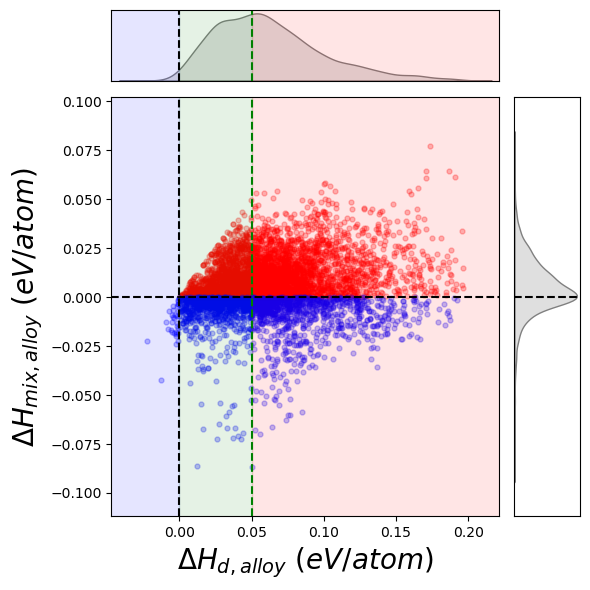

In [ ]:
dHm_list = combine_data_dict_to_list(dHm_dict)
dHd_list = combine_data_dict_to_list(dHd_dict)
formula_list = combine_data_dict_to_list(formula_dict)

positive, negative = count_postive_negative(dHm_list, np.zeros(len(dHm_list)))
n_percent = negative/(positive+negative)*100
p_percent = positive/(positive+negative)*100


count_stable = 0
count_metastable = 0
dHd_list = combine_data_dict_to_list(dHd_dict)
for dHd in dHd_list:
    if dHd<0:
        count_stable += 1
    elif dHd < 0.050:
        count_metastable += 1

print(f'total alloys: {len(dHd_list)}')
print('dHd:')
print('% stable alloys    :', round(count_stable/len(dHd_list)*100,1), '%')
print('% metastable alloys:', round(count_metastable/len(dHd_list)*100,1), '%')
print('% unstable alloys:', round((len(dHd_list)-count_stable-count_metastable)/len(dHd_list)*100,1), '%')
print('dHmix:')
print('% dHmix>0:', round(positive/(positive+negative)*100,1), '%')
print('% dHmix<0:', round(negative/(positive+negative)*100,1), '%')


fig = plt.figure(figsize=[6,6])
gs = fig.add_gridspec(6, 6)
ax1 = fig.add_subplot(gs[1:, 0:-1])
dist_ax_top = fig.add_subplot(gs[0:1, 0:-1], sharex=ax1)
dist_ax_right = fig.add_subplot(gs[1:, -1:], sharey=ax1)

dhm_lower, dhd_lower, formula_lower = [], [], []
dhm_higher, dhd_higher, formula_higher = [], [], []
for i in range(len(dHm_list)):
    if dHm_list[i]<0:
        dhm_lower.append(dHm_list[i])
        dhd_lower.append(dHd_list[i])
        formula_lower.append(formula_list[i])
    elif dHm_list[i]>0:
        dhm_higher.append(dHm_list[i])
        dhd_higher.append(dHd_list[i])
        formula_higher.append(formula_list[i])

ax1.scatter(dhd_higher, dhm_higher, c='red', marker='.', s=50, alpha=0.25, zorder = 0)
ax1.scatter(dhd_lower, dhm_lower, c='blue', marker='.', s=50, alpha=0.25, zorder = 0)

ax1.axvline(0, color='k', linestyle='--')
ax1.axvline(0.05, color='g', linestyle='--')
ax1.axhline(0, color='k', linestyle='--')
# ax1.plot([0.05, 0.05], [-100, 100], 'k:')

ax1.set_xlabel('$\Delta H_{d, alloy}$ ($eV/atom$)', fontsize=20)
ax1.set_xlim([min(dHd_list)-0.025,max(dHd_list)+0.025])
ax1.set_ylabel('$\Delta H_{mix, alloy}$ ($eV/atom$)', fontsize=20)
ax1.set_ylim([min(dHm_list)-0.025,max(dHm_list)+0.025])
ax1.fill_between(x=[-100,0], y1=[-100, -100], y2=[100, 100], color='blue', alpha=0.1)
ax1.fill_between(x=[0,0.05], y1=[-100, -100], y2=[100, 100], color='green', alpha=0.1)
ax1.fill_between(x=[0.05,100], y1=[-100, -100], y2=[100, 100], color='red', alpha=0.1)

# ax1.annotate('41.1%', xy=[0.05, 0.1], xytext =[-0.12, 0.1], fontsize=10, color='green',
#             arrowprops=dict(arrowstyle="<-", color='green'))
# ax1.text(-0.12, 0.08, 'Metastable perovskites', fontsize=10, color='green')
# ax1.text(-0.12, 0.06, '$\Delta H_d<0.05eV/atom$', fontsize=10, color='green')


# ax1.text(0.075, -0.225,str(int(round(n_percent,0)))+ '% alloys \nmore stable than $ABX_3$', color='blue', size=20)
# ax1.text(0.075, 0.16,str(int(round(p_percent,0)))+ '% alloys \nless stable than $ABX_3$', color='red', size=20)

sns.kdeplot(dHd_list, ax=dist_ax_top, fill=True, color='gray')
dist_ax_top.axvline(0, color='k', linestyle='--')
dist_ax_top.axvline(0.05, color='g', linestyle='--')
# dist_ax_top.axvline(0.05, color='k', linestyle=':')
# dist_ax_top.text(-0.1, dist_ax_top.get_ylim()[1]*0.6, '$\Delta H_d<0$\n0.6%', fontsize=10, color='blue')
# dist_ax_top.text(0.1, dist_ax_top.get_ylim()[1]*0.6, '$\Delta H_d>0$\n99.4%', fontsize=10, color='red')
dist_ax_top_ylim = [dist_ax_top.get_ylim()[0], dist_ax_top.get_ylim()[1]]
dist_ax_top.fill_between(x=[-100,0], y1=[0, 0], y2=[100, 100], color='blue', alpha=0.1)
dist_ax_top.fill_between(x=[0,0.05], y1=[0, 0], y2=[100, 100], color='green', alpha=0.1)
dist_ax_top.fill_between(x=[0.05,100], y1=[0, 0], y2=[100, 100], color='red', alpha=0.1)
dist_ax_top.set_ylim(dist_ax_top_ylim)
dist_ax_top.set_xlabel('')
dist_ax_top.set_ylabel('')
dist_ax_top.tick_params(labelbottom=False, labelleft=False)
dist_ax_top.get_xaxis().set_visible(False)
dist_ax_top.get_yaxis().set_visible(False)

sns.kdeplot(y=dHm_list, ax=dist_ax_right, fill=True, color='gray')
dist_ax_right.axhline(0, color='k', linestyle='--')
# dist_ax_right.text(dist_ax_right.get_xlim()[1]*0.1, -0.05, '$\Delta H_{mix}<0$\n36%', fontsize=10, color='blue')
# dist_ax_right.text(dist_ax_right.get_xlim()[1]*0.1, 0.05, '$\Delta H_{mix}>0$\n64%', fontsize=10, color='red')
dist_ax_right.set_xlabel('')
dist_ax_right.set_ylabel('')
dist_ax_right.tick_params(labelbottom=False, labelleft=False)
dist_ax_right.get_xaxis().set_visible(False)
dist_ax_right.get_yaxis().set_visible(False)

# ax1.tick_params(axis='both', major=True, labelsize=12)

fig.tight_layout()

plt.savefig('manuscript_figures/Figure_2_dHm_vs_dHd_alloys_clean.png', dpi=300)

plt.show()
    

In [42]:
less_stable_than_min = {'single':[],'alloy':[], 'max':[], 'formula':[]}
more_stable_than_min = {'single':[],'alloy':[], 'max':[], 'formula':[]}
more_stable_than_max = {'single':[],'alloy':[], 'min':[], 'formula':[]}
less_stable_than_max = {'single':[],'alloy':[], 'min':[], 'formula':[]}
dHd_list = combine_data_dict_to_list(dHd_dict)
min_dHd_list = combine_data_dict_to_list(min_dHd_dict)
max_dHd_list = combine_data_dict_to_list(max_dHd_dict)

for i in range(len(dHd_list)):
    dHd_min, dHd, dHd_max = min_dHd_list[i], dHd_list[i], max_dHd_list[i]
    formula = formula_list[i]
    if dHd_min<dHd:
        less_stable_than_min['single'].append(dHd_min)
        less_stable_than_min['alloy'].append(dHd)
        less_stable_than_min['max'].append(dHd_max)
        less_stable_than_min['formula'].append(formula)
    else:
        more_stable_than_min['single'].append(dHd_min)
        more_stable_than_min['alloy'].append(dHd)
        more_stable_than_min['max'].append(dHd_max)
        more_stable_than_min['formula'].append(formula)
        
    if dHd_max<dHd:
        less_stable_than_max['single'].append(dHd_max)
        less_stable_than_max['alloy'].append(dHd)
        less_stable_than_max['min'].append(dHd_min)
        less_stable_than_max['formula'].append(formula)
    else:
        more_stable_than_max['single'].append(dHd_max)
        more_stable_than_max['alloy'].append(dHd)
        more_stable_than_max['min'].append(dHd_min)
        more_stable_than_max['formula'].append(formula)

stable_alloy_dict = {'min':[],'alloy':[], 'max':[], 'formula':[]}
for i, form in enumerate(less_stable_than_min['formula']):
    dhdmin, alloy, dhdmax = less_stable_than_min['single'][i], less_stable_than_min['alloy'][i], less_stable_than_min['max'][i]
    if alloy<0:
        stable_alloy_dict['min'].append(dhdmin)
        stable_alloy_dict['alloy'].append(alloy)
        stable_alloy_dict['max'].append(dhdmax)
        stable_alloy_dict['formula'].append(form)

for i, form in enumerate(more_stable_than_min['formula']):
    dhdmin, alloy, dhdmax = more_stable_than_min['single'][i], more_stable_than_min['alloy'][i], more_stable_than_min['max'][i]
    if alloy<0:
        stable_alloy_dict['min'].append(dhdmin)
        stable_alloy_dict['alloy'].append(alloy)
        stable_alloy_dict['max'].append(dhdmax)
        stable_alloy_dict['formula'].append(form)

Number of alloys less stable than min $ABX_3$: 5820 97%
Number of alloys more stable than min $ABX_3$: 160 3%
Max $\Delta H_{d,ABX_3}^{min}$ ($eV/atom$): 0.015338092371471213

Number of alloys less stable than max $ABX_3$: 1590 27%
Number of alloys more stable than max $ABX_3$: 4390 73%
Max $\Delta H_{d,ABX_3}^{max}$ ($eV/atom$): 0.17437075220675702


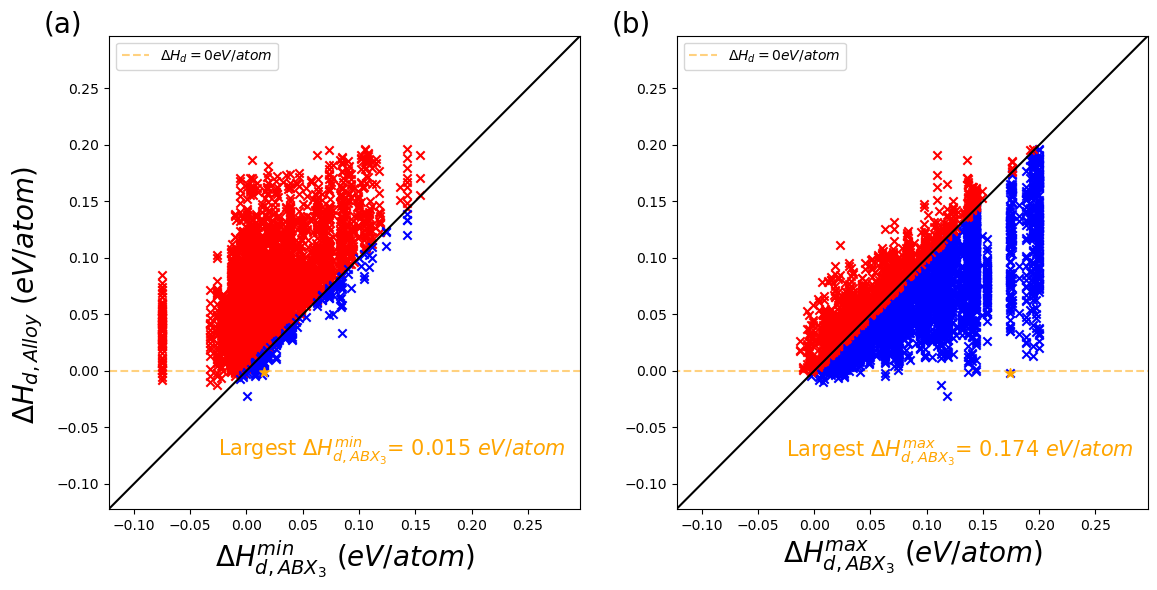

In [45]:
print('Number of alloys less stable than min $ABX_3$:', len(less_stable_than_min['single']), str(100-min_stable_percent)+'%')
print('Number of alloys more stable than min $ABX_3$:', len(more_stable_than_min['single']), str(min_stable_percent)+'%')
print('Max $\Delta H_{d,ABX_3}^{min}$ ($eV/atom$):', max(stable_alloy_dict['min']))
print()
print('Number of alloys less stable than max $ABX_3$:', len(less_stable_than_max['single']), str(100-max_stable_percent)+'%')
print('Number of alloys more stable than max $ABX_3$:', len(more_stable_than_max['single']), str(max_stable_percent)+'%')
print('Max $\Delta H_{d,ABX_3}^{max}$ ($eV/atom$):', max(stable_alloy_dict['max']))

fig, (ax1, ax2)= plt.subplots(1,2,figsize=[12,6])

min_stable_percent = int(round(len(more_stable_than_min['single'])/(len(less_stable_than_min['single'])+len(more_stable_than_min['single']))*100,0))
ax1.scatter(less_stable_than_min['single'], less_stable_than_min['alloy'], c='red', marker = 'x', alpha=1)#, label='less stable')
# ax1.text(0,0.21, str(len(less_stable_than_min['single']))+' alloys \n'+str(100-min_stable_percent)+'% less stable', color='red', size=20)
ax1.scatter(more_stable_than_min['single'], more_stable_than_min['alloy'], c='blue', marker = 'x', alpha=1)#, label='more stable')
# ax1.text(0.10,-0.025, str(len(more_stable_than_min['single']))+' alloys \n'+str(min_stable_percent)+'% more stable', color='blue', size=20)
# ax1.plot([-100,100],[0,0],c='k', ls='--', alpha=0.5)
ax1.plot([-100,100],[-100,100],'k')

max_stable_percent = int(round(len(more_stable_than_max['single'])/(len(more_stable_than_max['single'])+len(less_stable_than_max['single']))*100,0))
ax2.scatter(more_stable_than_max['single'], more_stable_than_max['alloy'], c='blue', marker = 'x', alpha=1)#, label='more stable')
# ax2.text(0.10,-0.1, str(len(more_stable_than_max['single']))+' alloys \n'+str(max_stable_percent)+'% more stable', color='blue', size=20)
ax2.scatter(less_stable_than_max['single'], less_stable_than_max['alloy'], c='red', marker = 'x', alpha=1)#, label='less stable')
# ax2.text(0,0.21, str(len(less_stable_than_max['single']))+' alloys \n'+str(100-max_stable_percent)+'% less stable', color='red', size=20)
# ax2.plot([-100,100],[0,0],c='k', ls='--', alpha=0.5)
ax2.plot([-100,100],[-100,100],'k')


point_highlight_color = '#FFA500'

ax1.scatter(max(stable_alloy_dict['min']), stable_alloy_dict['alloy'][stable_alloy_dict['min'].index(max(stable_alloy_dict['min']))], c=point_highlight_color, marker = '*', s=50, alpha=1, zorder=2)
ax1.text(-0.025, stable_alloy_dict['alloy'][stable_alloy_dict['min'].index(max(stable_alloy_dict['min']))]-0.075, 'Largest $\Delta H_{d,ABX_3}^{min}$= '+str(round(max(stable_alloy_dict['min']),3))+' $eV/atom$', color=point_highlight_color, size=15)
ax1.plot([-100,100],[0,0],c=point_highlight_color, ls='--', alpha=0.5, zorder=0, label='$\Delta H_d=0eV/atom$')

ax2.scatter(max(stable_alloy_dict['max']), stable_alloy_dict['alloy'][stable_alloy_dict['max'].index(max(stable_alloy_dict['max']))], c=point_highlight_color, marker = '*', s=50, alpha=1, zorder=2)
ax2.text(-0.025, stable_alloy_dict['alloy'][stable_alloy_dict['max'].index(max(stable_alloy_dict['max']))]-0.075, 'Largest $\Delta H_{d,ABX_3}^{max}$= '+str(round(max(stable_alloy_dict['max']),3))+' $eV/atom$', color=point_highlight_color, size=15)
ax2.plot([-100,100],[0,0],c=point_highlight_color, ls='--', alpha=0.5, zorder=0, label='$\Delta H_d=0eV/atom$')


# ax1.plot([0.1,0.1],[-1,1], color='black', lw=0.5, ls='--')
# ax1.plot([-1,1],[0.1,0.1], color='black', lw=0.5, ls='--')
# ax2.plot([0.1,0.1],[-1,1], color='black', lw=0.5, ls='--')
# ax2.plot([-1,1],[0.1,0.1], color='black', lw=0.5, ls='--')


ax1.set_xlim([min(dHd_list)-0.1,max(dHd_list)+0.1])
ax1.set_ylim([min(dHd_list)-0.1,max(dHd_list)+0.1])
ax2.set_xlim([min(dHd_list)-0.1,max(dHd_list)+0.1])
ax2.set_ylim([min(dHd_list)-0.1,max(dHd_list)+0.1])
# bottom_ax1.set_xlim([-0.05,0.3])
# bottom_ax2.set_xlim([-0.05,0.3])
ax1.grid(False)
ax2.grid(False)

ax1.set_xlabel('$\Delta H_{d,ABX_3}^{min}$ ($eV/atom$)', fontsize=20)
ax2.set_xlabel('$\Delta H_{d,ABX_3}^{max}$ ($eV/atom$)', fontsize=20)
# ax1.set_xlabel('$min\{\Delta H_{d}\}_{ABX_3}$ ($eV/atom$)', fontsize=20)
# ax2.set_xlabel('$max\{\Delta H_{d}\}_{ABX_3}$ ($eV/atom$)', fontsize=20)


fig.supylabel('$\Delta H_{d, Alloy}$ ($eV/atom$)', fontsize=20)
# fig.supxlabel('$ABX_3\ \Delta H_{d}$ ($meV/atom$)', fontsize=15)

ax1.text(-0.18,0.3, '(a)', fontsize=20)
ax2.text(-0.18,0.3, '(b)', fontsize=20)

fig.tight_layout()
ax1.legend()
ax2.legend()
plt.savefig('manuscript_figures/Figure_3_alloy_min_max_dHf_clean.png', dpi=300)
plt.show()


# Add Entropy Analysis

In [46]:
#function to determine if doubleA or not based on formula
def is_double_A(formula, fraction):
    '''
    determine if formula corresponds to 'double A site' alloy based on formula and fraction to determine if composition has 2 or 4 constituents. 
    :param formula: formula of alloy
    :param fraction: fraction of alloy (0, 0.25, 0.5, 0.75, 1)
    :return: True if double A site alloy, False if not
    '''
    els_tuple = get_els_tuple(formula)
    if fraction in [0, 1]:
        if len(els_tuple)==4:
            #AA'B2X6, treat the same as A2BB'X6 (single A, doubleB) for the purposes of calculating entropy. both have the same dS because they both have 2 constituent single perovskite
            return True, fraction
        elif len(els_tuple)==3:
            return False, fraction
    else:
        if len(els_tuple)==5:
            return True, fraction
        else:
            return False, fraction


def regular_solution_model(x, doubleA=False):
    '''
    calculate entropy using the regular solution model
    :param x: mol fraction of component A in A(x)B(1-x)
    :return: delta S
    '''
    k_B = 8.617333262e-5  # Boltzmann constant in eV/K
    if x != 0 and x != 1:
        if doubleA:
            x1 = x / 2
            x2 = (1-x) / 2
            #1/2 AA'(B_xB'_1-x)2X6 -> x/2 ABX3 + x/2 A'BX3 + (1-x)/2 AB'X3 + (1-x)/2 A'B'X3
            dS = - k_B * (x1 * np.log(x1) + x1 * np.log(x1) + x2 * np.log(x2) + x2 * np.log(x2))
        else:
            x1 = x
            x2 = 1 - x
            dS = - k_B * (x1 * np.log(x1) + x2 * np.log(x2))
    else:
        if doubleA:
            #at x=0 or 1, we have 1/2 AA'B2X6 -> 0.5 ABX3 + 0.5 AB'X3
            dS = - k_B * (0.5 * np.log(0.5) + 0.5 * np.log(0.5))
        else:
            dS = 0
    return dS

In [49]:
dSm_dict = {'F':[], 'Cl':[], 'Br':[], 'I':[]}

frac_str_list = ['0', '25', '50', '75', '100']
frac_flt_list = [0, 0.25, 0.5, 0.75, 1]

interesting_list_entropy_calc = []
missing_list_entropy_calc = []
good_list_entropy_calc = []
done_comp_entropy_calc = []
for alloy_set, v in calced_E_dict.items():
    for frac_str in frac_str_list:
        formula = v[frac_str]['formula']
        frac = frac_flt_list[frac_str_list.index(frac_str)]
        doubleA, frac_for_entropy = is_double_A(formula, frac)
        
        # all alloys
        Etot = v[frac_str]['osm']['sqs']['E_tot_atom']
        dHf = get_dHf(formula, Etot)
        dHd = v[frac_str]['osm']['sqs']['dHd']
        Etot_linear = v[frac_str]['osm']['sqs']['Etot_linear']
        dHf_linear = get_dHf(formula, Etot_linear)
        dHd_linear = v[frac_str]['osm']['sqs']['dHd_linear']
        dHm = dHf - dHf_linear # or Etot_atom - Etot_linear
        dSm = regular_solution_model(frac_for_entropy, doubleA=doubleA)
        dHd_min = v[frac_str]['osm']['sqs']['dHd_min']
        dHd_max = v[frac_str]['osm']['sqs']['dHd_max']
        formula_min = v[frac_str]['osm']['sqs']['formula_min']
        formula_max = v[frac_str]['osm']['sqs']['formula_max']
        
        
        if not formula in done_comp_entropy_calc:
            done_comp_entropy_calc.append(formula)
            if not np.isnan(dHd) and not np.isnan(dHd_linear) and dHd!=dHd_linear:# and frac_str not in ['0','100']:
                good_list_entropy_calc.append(formula)
                for X in ['F', 'Cl', 'Br', 'I']:
                    append_to_dict_list(dSm_dict, X, alloy_set, X+'6', dSm)
                
                if dHd-dHd_linear>0.1:
                    print(v[frac_str]['formula'], alloy_set, frac_str, dHd, dHd_linear)
                if dHf<dHf_linear:# and np.abs(dHd-dHd_linear)>0.005:
                    interesting_list_entropy_calc.append(v[frac_str]['formula'])
                    
            elif np.isnan(dHd):
                missing_list_entropy_calc.append(formula)
            else:
                good_list_entropy_calc.append(formula)
            

missing_list_entropy_calc = list(set(missing_list_entropy_calc))
good_list_entropy_calc = list(set(good_list_entropy_calc))


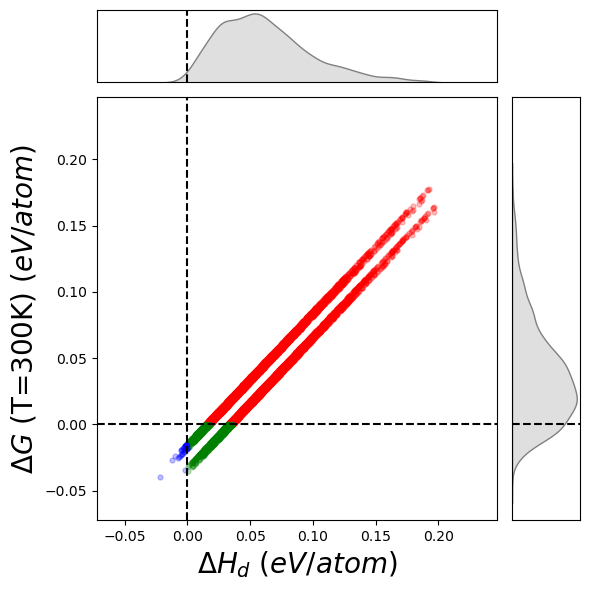

enthalpy
0.6% alloys stable
99.4% alloys unstable
Free energy
% stable alloys    : 15.0 %
% metastable alloys: 0.0 %
% unstable alloys  : 85.0 %


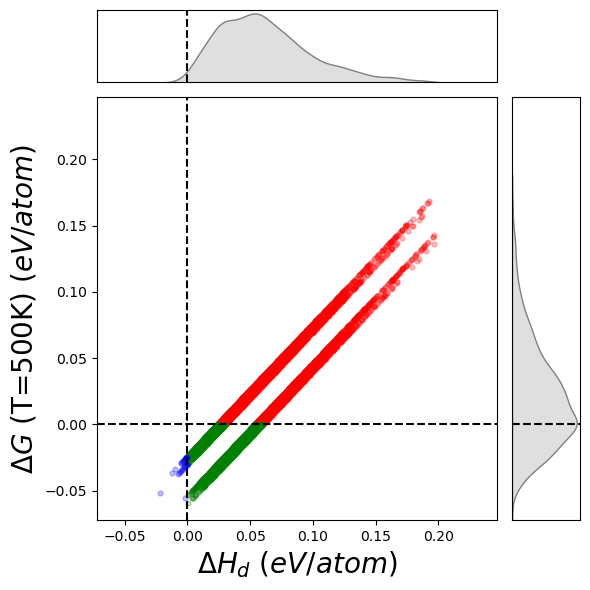

enthalpy
0.6% alloys stable
99.4% alloys unstable
Free energy
% stable alloys    : 33.5 %
% metastable alloys: 0.0 %
% unstable alloys  : 66.5 %


In [50]:
T=300

dHm_list = combine_data_dict_to_list(dHm_dict)
dSm_list = combine_data_dict_to_list(dSm_dict)
dHd_list = combine_data_dict_to_list(dHd_dict)
formula_list = combine_data_dict_to_list(formula_dict)

Ts = [300, 500]
Fig_labels = ['S6', 'S7']

for T, Fig_label in zip(Ts, Fig_labels):

    dGm_list = [dHm-T*dSm for dHm, dSm in zip(dHm_list, dSm_list)]
    dGd_list = [dHd-T*dSm for dHd, dSm in zip(dHd_list, dSm_list)]
    TdS_list = [T*dSm for dSm in dSm_list]

    positive, negative = count_postive_negative(dHd_list, np.zeros(len(dHd_list)))
    n_percent = negative/(positive+negative)*100
    p_percent = positive/(positive+negative)*100

    fig = plt.figure(figsize=[6,6])
    gs = fig.add_gridspec(6, 6)
    ax1 = fig.add_subplot(gs[1:, 0:-1])
    dist_ax_top = fig.add_subplot(gs[0:1, 0:-1], sharex=ax1)
    dist_ax_right = fig.add_subplot(gs[1:, -1:], sharey=ax1)

    dGd_lower, dHd_lower, formula_lower = [], [], []
    dGd_higher, dHd_higher, formula_higher = [], [], []
    dGd_T_stabilized, dHd_T_stabilized, formula_T_stabilized = [], [], []
    for i in range(len(dGd_list)):
        if dGd_list[i]<0:
            if dHd_list[i]<0:
                dGd_lower.append(dGd_list[i])
                dHd_lower.append(dHd_list[i])
                formula_lower.append(formula_list[i])
            else:
                dGd_T_stabilized.append(dGd_list[i])
                dHd_T_stabilized.append(dHd_list[i])
                formula_T_stabilized.append(formula_list[i])
        elif dGd_list[i]>0:
            dGd_higher.append(dGd_list[i])
            dHd_higher.append(dHd_list[i])
            formula_higher.append(formula_list[i])

    ax1.scatter(dHd_higher, dGd_higher, c='red', marker='.', s=50, alpha=0.25, zorder = 0)
    ax1.scatter(dHd_T_stabilized, dGd_T_stabilized, c='green', marker='.', s=50, alpha=0.25, zorder = 0)
    ax1.scatter(dHd_lower, dGd_lower, c='blue', marker='.', s=50, alpha=0.25, zorder = 0)

    ax1.axvline(0, color='k', linestyle='--')
    ax1.axhline(0, color='k', linestyle='--')
    # ax1.plot([0.05, 0.05], [-100, 100], 'k:')

    ax1.set_xlabel(f'$\Delta H_d$ ($eV/atom$)', fontsize=20)
    ax1.set_xlim([min(dHd_list)-0.05,max(dHd_list)+0.05])
    ax1.set_ylabel(f'$\Delta G$ (T={T:.0f}K) ($eV/atom$)', fontsize=20)
    # ax1.set_ylim([min(dGd_list)-0.05,max(dGd_list)+0.05])
    ax1.set_ylim([min(dHd_list)-0.05,max(dHd_list)+0.05])


    sns.kdeplot(dHd_list, ax=dist_ax_top, fill=True, color='gray')
    dist_ax_top.axvline(0, color='k', linestyle='--')
    dist_ax_top_ylim = [dist_ax_top.get_ylim()[0], dist_ax_top.get_ylim()[1]]
    dist_ax_top.set_ylim(dist_ax_top_ylim)
    dist_ax_top.set_xlabel('')
    dist_ax_top.set_ylabel('')
    dist_ax_top.tick_params(labelbottom=False, labelleft=False)
    dist_ax_top.get_xaxis().set_visible(False)
    dist_ax_top.get_yaxis().set_visible(False)

    sns.kdeplot(y=dGd_list, ax=dist_ax_right, fill=True, color='gray')
    dist_ax_right.axhline(0, color='k', linestyle='--')
    dist_ax_right.set_xlabel('')
    dist_ax_right.set_ylabel('')
    dist_ax_right.tick_params(labelbottom=False, labelleft=False)
    dist_ax_right.get_xaxis().set_visible(False)
    dist_ax_right.get_yaxis().set_visible(False)

    fig.tight_layout()

    plt.savefig(f'manuscript_figures/Figure_{Fig_label}_dGd_T{int(T)}_vs_dHd_alloys_clean.png', dpi=300)

    plt.show()

    print('enthalpy')
    print(str(round(n_percent,1))+ '% alloys stable')
    print(str(round(p_percent,1))+ '% alloys unstable')


    count_stable = 0
    count_metastable = 0
    for dGd in dGd_list:
        if dGd<0:
            count_stable += 1
        # elif dGd < 0.050:
        #     count_metastable += 1
    print('Free energy')
    print('% stable alloys    :', round(count_stable/len(dGd_list)*100,1), '%')
    print('% metastable alloys:', round(count_metastable/len(dGd_list)*100,1), '%')
    print('% unstable alloys  :', round((len(dGd_list)-count_stable-count_metastable)/len(dGd_list)*100,1), '%')